In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Image

base_dir = Path(".")
if not (base_dir / "final_summary.csv").exists():
    base_dir = Path("final/final 2")

out_dir = base_dir / "coursework_outputs"
out_dir.mkdir(parents=True, exist_ok=True)

summary = pd.read_csv(base_dir / "final_summary.csv")
grouped = pd.read_csv(base_dir / "final_grouped.csv")
ratio = pd.read_csv(base_dir / "final_ratio.csv")
bad = pd.read_csv(base_dir / "final_bad_runs.csv")

print("base_dir:", base_dir)
print("out_dir:", out_dir)
print("summary:", summary.shape)
print("grouped:", grouped.shape)
print("ratio:", ratio.shape)


base_dir: .
out_dir: coursework_outputs
summary: (33, 42)
grouped: (18, 17)
ratio: (6, 14)


In [2]:
valid = summary[(summary["dtype"].isin(["fp32", "fp64"])) & summary["best_l2_error"].notna()].copy()
fp16 = summary[summary["dtype"] == "fp16"].copy()

cols = [
    "run_id", "task_name", "variant", "case_name", "case_value", "dtype", "seed",
    "best_l2_error", "final_l2_error", "final_loss", "best_step", "elapsed_time", "run_name",
]
valid_runs = valid[cols].sort_values(["task_name", "variant", "case_value", "dtype", "seed"])
valid_runs.to_csv(out_dir / "valid_fp32_fp64_runs.csv", index=False)

fp16_cols = ["run_id", "task_name", "variant", "case_name", "case_value", "dtype", "seed", "best_l2_error", "final_l2_error", "elapsed_time", "error"]
fp16[fp16_cols].to_csv(out_dir / "fp16_runs.csv", index=False)

display(valid_runs)


,run_id,task_name,variant,case_name,case_value,dtype,seed,best_l2_error,final_l2_error,final_loss,best_step,elapsed_time,run_name
0,1,burgers1d,burgers_more_points,nu,0.001,fp32,0,0.040777,0.040974,0.000049,4700.0,496.673552,run001_burgers1d_burgers_more_points_nu0p001_f...
1,2,burgers1d,burgers_more_points,nu,0.001,fp32,1,0.148914,0.151424,0.000803,4100.0,508.334411,run002_burgers1d_burgers_more_points_nu0p001_f...
2,3,burgers1d,burgers_more_points,nu,0.001,fp64,0,0.176749,0.176749,0.000432,5000.0,663.149723,run003_burgers1d_burgers_more_points_nu0p001_f...
3,4,burgers1d,burgers_more_points,nu,0.001,fp64,1,0.163189,0.167251,0.000082,4300.0,664.320619,run004_burgers1d_burgers_more_points_nu0p001_f...
6,7,burgers1d,burgers_more_points,nu,0.002,fp32,0,0.050356,0.050555,0.000079,4200.0,440.537607,run007_burgers1d_burgers_more_points_nu0p002_f...
7,8,burgers1d,burgers_more_points,nu,0.002,fp32,1,0.047201,0.050376,0.000021,3900.0,494.510916,run008_burgers1d_burgers_more_points_nu0p002_f...
8,9,burgers1d,burgers_more_points,nu,0.002,fp64,0,0.046760,0.050524,0.000007,3600.0,662.067112,run009_burgers1d_burgers_more_points_nu0p002_f...
9,10,burgers1d,burgers_more_points,nu,0.002,fp64,1,0.046287,0.050410,0.000009,3800.0,678.935207,run010_burgers1d_burgers_more_points_nu0p002_f...
24,25,convection1d,convection_beta30_lbfgs_grid,beta,30.000,fp32,0,0.008039,0.008039,0.000041,1200.0,467.592657,run025_convection1d_convection_beta30_lbfgs_gr...
25,26,convection1d,convection_beta30_lbfgs_grid,beta,30.000,fp32,1,0.013844,0.013844,0.000070,1000.0,478.715564,run026_convection1d_convection_beta30_lbfgs_gr...


In [3]:
g = grouped[grouped["dtype"].isin(["fp32", "fp64"])].copy()
g_cols = [
    "task_name", "variant", "case_name", "case_value", "dtype",
    "best_l2_error_mean", "best_l2_error_std", "best_l2_error_min", "best_l2_error_max",
    "final_l2_error_mean", "elapsed_time_mean",
]
g = g[g_cols].sort_values(["task_name", "variant", "case_value", "dtype"])
g.to_csv(out_dir / "grouped_fp32_fp64.csv", index=False)
display(g)


,task_name,variant,case_name,case_value,dtype,best_l2_error_mean,best_l2_error_std,best_l2_error_min,best_l2_error_max,final_l2_error_mean,elapsed_time_mean
1,burgers1d,burgers_more_points,nu,0.001,fp32,0.094845,0.076464,0.040777,0.148914,0.096199,502.503982
2,burgers1d,burgers_more_points,nu,0.001,fp64,0.169969,0.009588,0.163189,0.176749,0.172000,663.735171
4,burgers1d,burgers_more_points,nu,0.002,fp32,0.048779,0.002231,0.047201,0.050356,0.050466,467.524262
5,burgers1d,burgers_more_points,nu,0.002,fp64,0.046524,0.000335,0.046287,0.046760,0.050467,670.501160
7,convection1d,convection_beta30_lbfgs_grid,beta,30.000,fp32,0.010941,0.004105,0.008039,0.013844,0.010941,473.154110
8,convection1d,convection_beta30_lbfgs_grid,beta,30.000,fp64,0.006625,0.000166,0.006508,0.006743,0.006710,450.424339
10,convection1d,convection_beta50_wide_lbfgs,beta,50.000,fp32,0.687307,NaN,0.687307,0.687307,0.687307,1088.638228
11,convection1d,convection_beta50_wide_lbfgs,beta,50.000,fp64,0.007182,NaN,0.007182,0.007182,0.007182,2370.150009
13,helmholtz1d,helmholtz_resample_long,m,8.000,fp32,0.003250,0.000133,0.003156,0.003344,0.003250,131.208901
14,helmholtz1d,helmholtz_resample_long,m,8.000,fp64,0.115449,0.161749,0.001076,0.229823,0.115450,124.947947


In [4]:
r = ratio.copy()
if "fp64_over_fp32_best" in r.columns:
    r["fp64_result"] = "similar"
    r.loc[r["fp64_over_fp32_best"] < 0.8, "fp64_result"] = "fp64 better"
    r.loc[r["fp64_over_fp32_best"] > 1.25, "fp64_result"] = "fp32 better"

keep = [
    "task_name", "variant", "case_name", "case_value",
    "fp32_best_l2_error_mean", "fp64_best_l2_error_mean",
    "fp32_final_l2_error_mean", "fp64_final_l2_error_mean",
    "fp64_over_fp32_best", "fp64_over_fp32_final", "fp64_result",
]
keep = [c for c in keep if c in r.columns]
r = r[keep].sort_values(["task_name", "variant", "case_value"])
r.to_csv(out_dir / "fp64_vs_fp32_ratio.csv", index=False)
display(r)


,task_name,variant,case_name,case_value,fp32_best_l2_error_mean,fp64_best_l2_error_mean,fp32_final_l2_error_mean,fp64_final_l2_error_mean,fp64_over_fp32_best,fp64_over_fp32_final,fp64_result
0,burgers1d,burgers_more_points,nu,0.001,0.094845,0.169969,0.096199,0.172000,1.792065,1.787958,fp32 better
1,burgers1d,burgers_more_points,nu,0.002,0.048779,0.046524,0.050466,0.050467,0.953769,1.000028,similar
2,convection1d,convection_beta30_lbfgs_grid,beta,30.000,0.010941,0.006625,0.010941,0.006710,0.605541,0.613321,fp64 better
3,convection1d,convection_beta50_wide_lbfgs,beta,50.000,0.687307,0.007182,0.687307,0.007182,0.010449,0.010449,fp64 better
4,helmholtz1d,helmholtz_resample_long,m,8.000,0.003250,0.115449,0.003250,0.115450,35.524190,35.524226,fp32 better
5,helmholtz1d,helmholtz_resample_long,m,12.000,0.012531,0.002114,0.012531,0.002548,0.168675,0.203348,fp64 better


In [5]:
table = r.copy()
table["case"] = table["task_name"] + " " + table["case_name"] + "=" + table["case_value"].astype(str)
cols2 = [
    "case", "variant", "fp32_best_l2_error_mean", "fp64_best_l2_error_mean",
    "fp64_over_fp32_best", "fp64_result",
]
cols2 = [c for c in cols2 if c in table.columns]
table = table[cols2]
table.to_csv(out_dir / "coursework_main_table.csv", index=False)
display(table)


,case,variant,fp32_best_l2_error_mean,fp64_best_l2_error_mean,fp64_over_fp32_best,fp64_result
0,burgers1d nu=0.001,burgers_more_points,0.094845,0.169969,1.792065,fp32 better
1,burgers1d nu=0.002,burgers_more_points,0.048779,0.046524,0.953769,similar
2,convection1d beta=30.0,convection_beta30_lbfgs_grid,0.010941,0.006625,0.605541,fp64 better
3,convection1d beta=50.0,convection_beta50_wide_lbfgs,0.687307,0.007182,0.010449,fp64 better
4,helmholtz1d m=8.0,helmholtz_resample_long,0.003250,0.115449,35.524190,fp32 better
5,helmholtz1d m=12.0,helmholtz_resample_long,0.012531,0.002114,0.168675,fp64 better


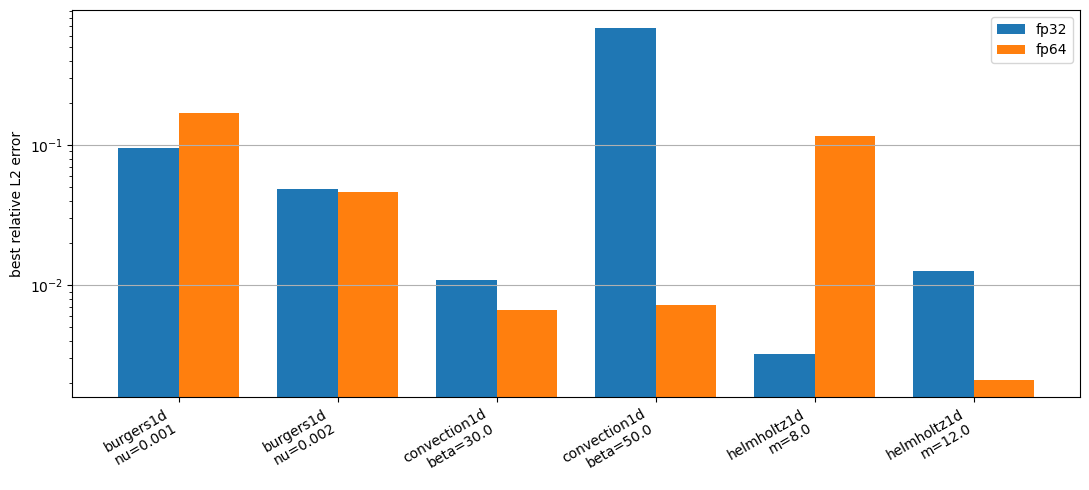

In [6]:
plot_df = r.dropna(subset=["fp32_best_l2_error_mean", "fp64_best_l2_error_mean"]).copy()
plot_df["label"] = plot_df["task_name"] + "\n" + plot_df["case_name"] + "=" + plot_df["case_value"].astype(str)

x = np.arange(len(plot_df))
w = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w / 2, plot_df["fp32_best_l2_error_mean"], width=w, label="fp32")
ax.bar(x + w / 2, plot_df["fp64_best_l2_error_mean"], width=w, label="fp64")
ax.set_yscale("log")
ax.set_ylabel("best relative L2 error")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["label"], rotation=30, ha="right")
ax.grid(True, axis="y")
ax.legend()
fig.tight_layout()
fig.savefig(out_dir / "best_l2_fp32_fp64_bar.png", dpi=180)
plt.show()


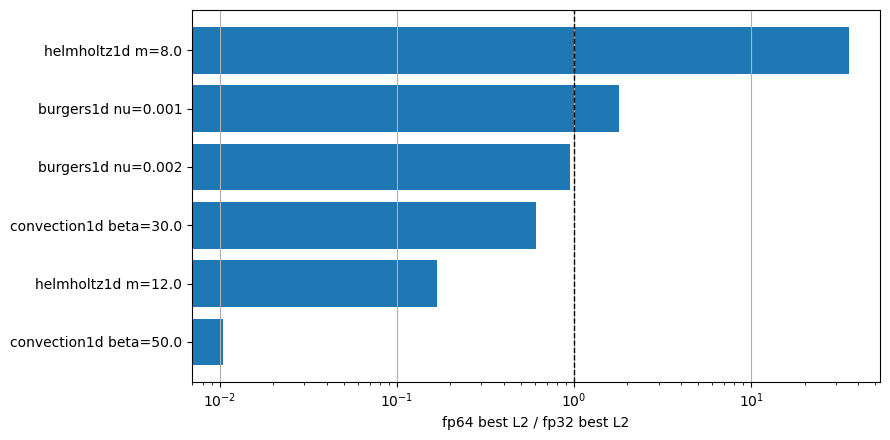

In [7]:
plot_df = r.dropna(subset=["fp64_over_fp32_best"]).copy()
plot_df = plot_df.sort_values("fp64_over_fp32_best")
plot_df["label"] = plot_df["task_name"] + " " + plot_df["case_name"] + "=" + plot_df["case_value"].astype(str)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(plot_df["label"], plot_df["fp64_over_fp32_best"])
ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("fp64 best L2 / fp32 best L2")
ax.grid(True, axis="x")
fig.tight_layout()
fig.savefig(out_dir / "fp64_over_fp32_ratio.png", dpi=180)
plt.show()


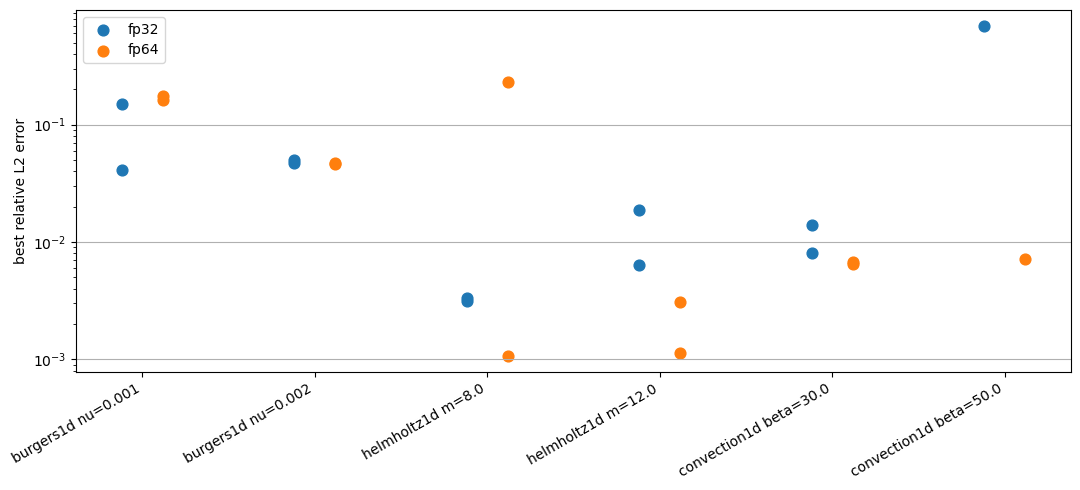

In [8]:
seed_df = valid.copy()
seed_df["label"] = seed_df["task_name"] + " " + seed_df["case_name"] + "=" + seed_df["case_value"].astype(str)
labels = list(seed_df["label"].drop_duplicates())
pos = {v: i for i, v in enumerate(labels)}
colors = {"fp32": "tab:blue", "fp64": "tab:orange"}

fig, ax = plt.subplots(figsize=(11, 5))
for dtype in ["fp32", "fp64"]:
    cur = seed_df[seed_df["dtype"] == dtype]
    xs = [pos[v] + (-0.12 if dtype == "fp32" else 0.12) for v in cur["label"]]
    ax.scatter(xs, cur["best_l2_error"], label=dtype, color=colors[dtype], s=60)
ax.set_yscale("log")
ax.set_ylabel("best relative L2 error")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.grid(True, axis="y")
ax.legend()
fig.tight_layout()
fig.savefig(out_dir / "seed_scatter_best_l2.png", dpi=180)
plt.show()


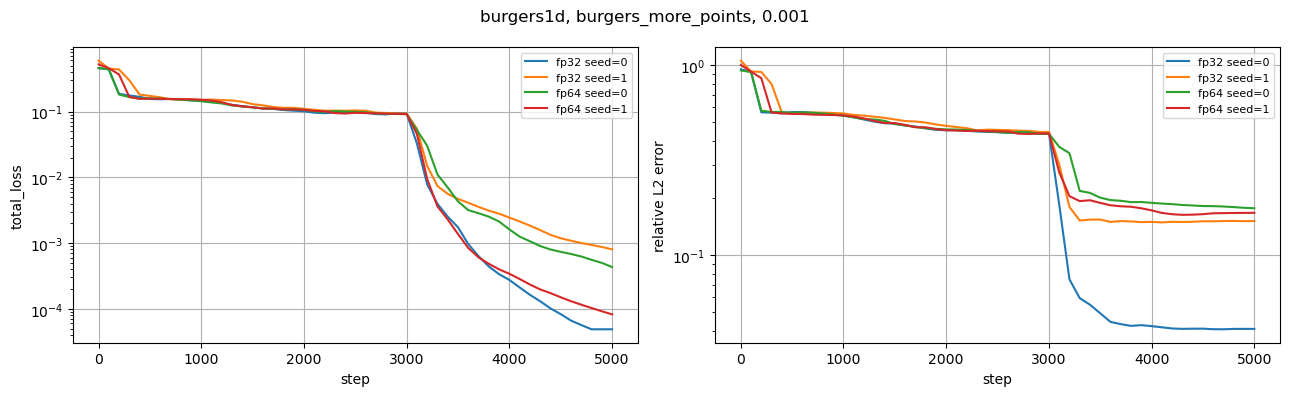

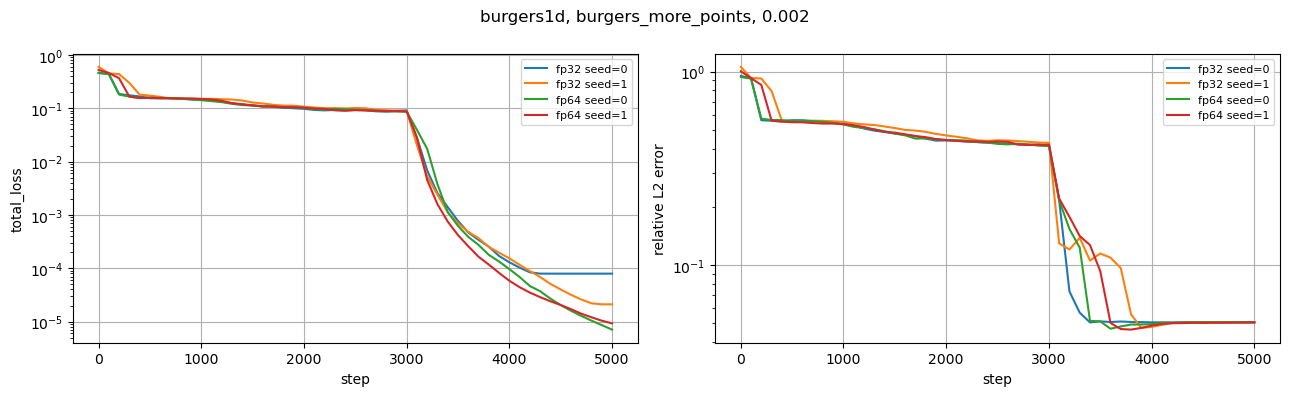

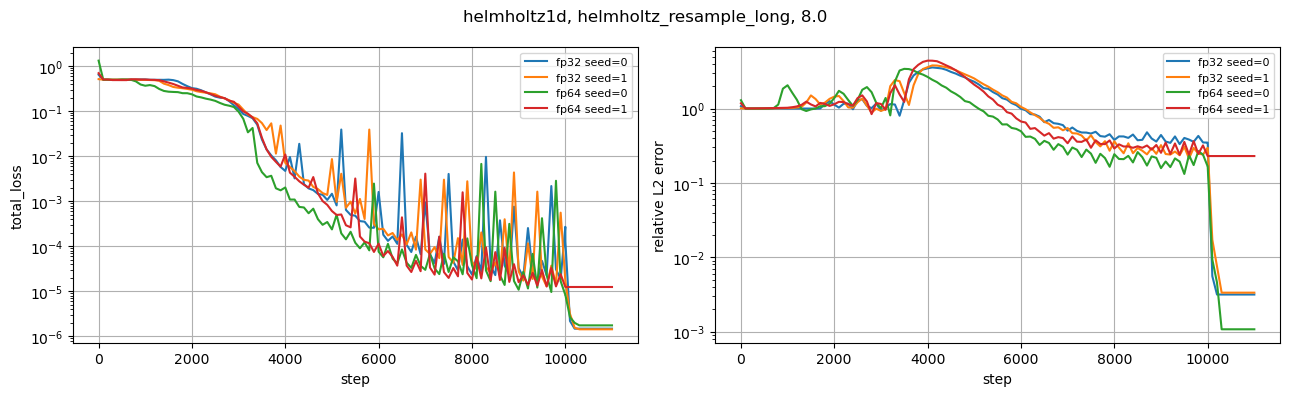

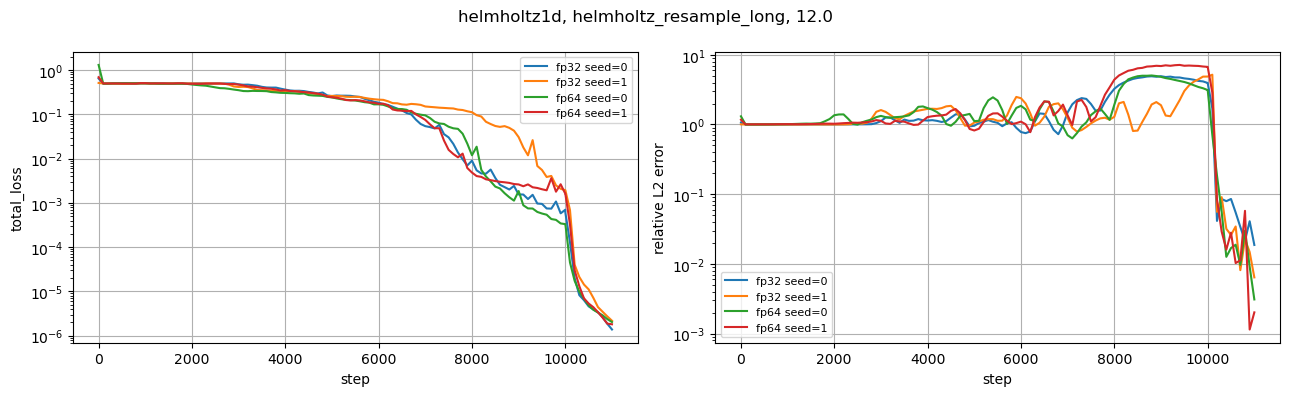

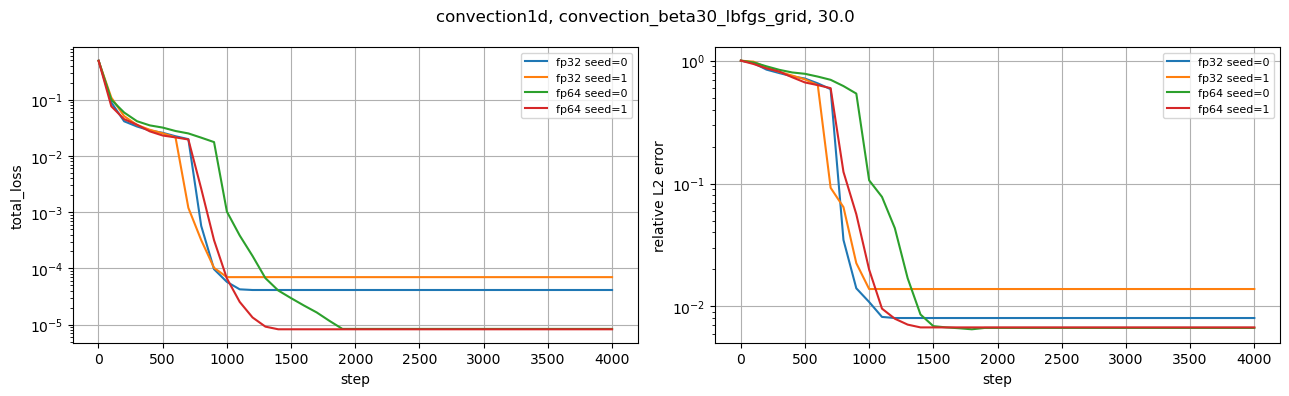

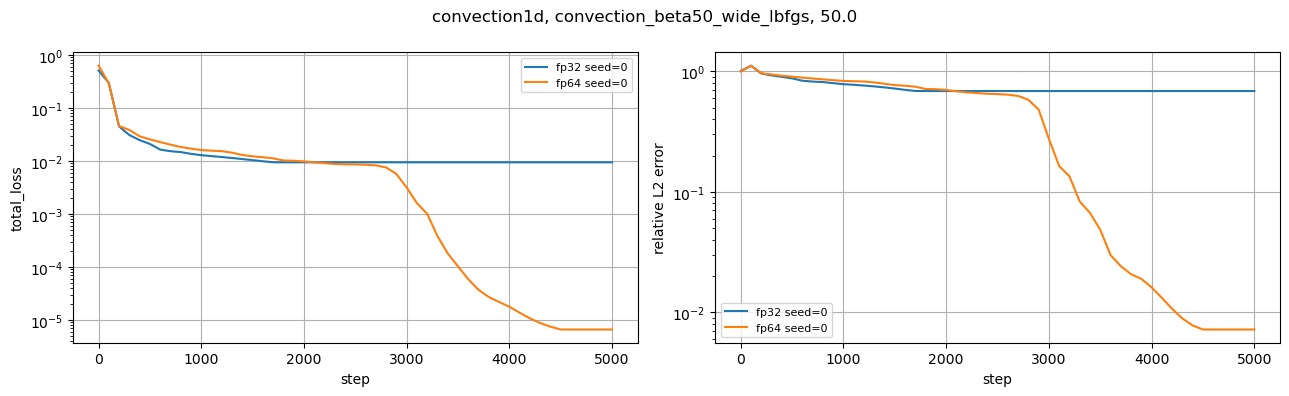

[PosixPath('coursework_outputs/curves_burgers1d_burgers_more_points_0p001.png'),
 PosixPath('coursework_outputs/curves_burgers1d_burgers_more_points_0p002.png'),
 PosixPath('coursework_outputs/curves_helmholtz1d_helmholtz_resample_long_8p0.png'),
 PosixPath('coursework_outputs/curves_helmholtz1d_helmholtz_resample_long_12p0.png'),
 PosixPath('coursework_outputs/curves_convection1d_convection_beta30_lbfgs_grid_30p0.png'),
 PosixPath('coursework_outputs/curves_convection1d_convection_beta50_wide_lbfgs_50p0.png')]

In [9]:
def metric_path(row):
    return base_dir / "runs" / row["run_name"] / "metrics.csv"

def save_curves(task_name, variant, case_value):
    cur = valid[(valid["task_name"] == task_name) & (valid["variant"] == variant) & (valid["case_value"] == case_value)]
    if len(cur) == 0:
        return None
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ok = 0
    for row in cur.sort_values(["dtype", "seed"]).itertuples():
        p = metric_path(row._asdict())
        if not p.exists():
            continue
        h = pd.read_csv(p)
        label = f"{row.dtype} seed={row.seed}"
        ax[0].plot(h["step"], h["total_loss"], label=label)
        ax[1].plot(h["step"], h["l2_error"], label=label)
        ok += 1
    if ok == 0:
        plt.close(fig)
        return None
    ax[0].set_yscale("log")
    ax[1].set_yscale("log")
    ax[0].set_xlabel("step")
    ax[1].set_xlabel("step")
    ax[0].set_ylabel("total_loss")
    ax[1].set_ylabel("relative L2 error")
    ax[0].grid(True)
    ax[1].grid(True)
    ax[0].legend(fontsize=8)
    ax[1].legend(fontsize=8)
    title = f"{task_name}, {variant}, {case_value}"
    fig.suptitle(title)
    fig.tight_layout()
    name = f"curves_{task_name}_{variant}_{str(case_value).replace('.', 'p')}.png"
    p = out_dir / name
    fig.savefig(p, dpi=180)
    plt.show()
    return p

curve_files = []
for row in valid[["task_name", "variant", "case_value"]].drop_duplicates().itertuples(index=False):
    p = save_curves(row.task_name, row.variant, row.case_value)
    if p is not None:
        curve_files.append(p)

curve_files


In [10]:
good_cases = r[r.get("fp64_result", "") == "fp64 better"].copy()
good_cases.to_csv(out_dir / "fp64_better_cases.csv", index=False)

bad_non_fp16 = bad[bad["dtype"].isin(["fp32", "fp64"])].copy()
bad_non_fp16.to_csv(out_dir / "bad_runs_fp32_fp64.csv", index=False)

print("saved files:")
for p in sorted(out_dir.glob("*")):
    print(p.name)


saved files:
bad_runs_fp32_fp64.csv
best_l2_fp32_fp64_bar.png
coursework_main_table.csv
curves_burgers1d_burgers_more_points_0p001.png
curves_burgers1d_burgers_more_points_0p002.png
curves_convection1d_convection_beta30_lbfgs_grid_30p0.png
curves_convection1d_convection_beta50_wide_lbfgs_50p0.png
curves_helmholtz1d_helmholtz_resample_long_12p0.png
curves_helmholtz1d_helmholtz_resample_long_8p0.png
fp16_runs.csv
fp64_better_cases.csv
fp64_over_fp32_ratio.png
fp64_vs_fp32_ratio.csv
grouped_fp32_fp64.csv
seed_scatter_best_l2.png
valid_fp32_fp64_runs.csv


best_l2_fp32_fp64_bar.png


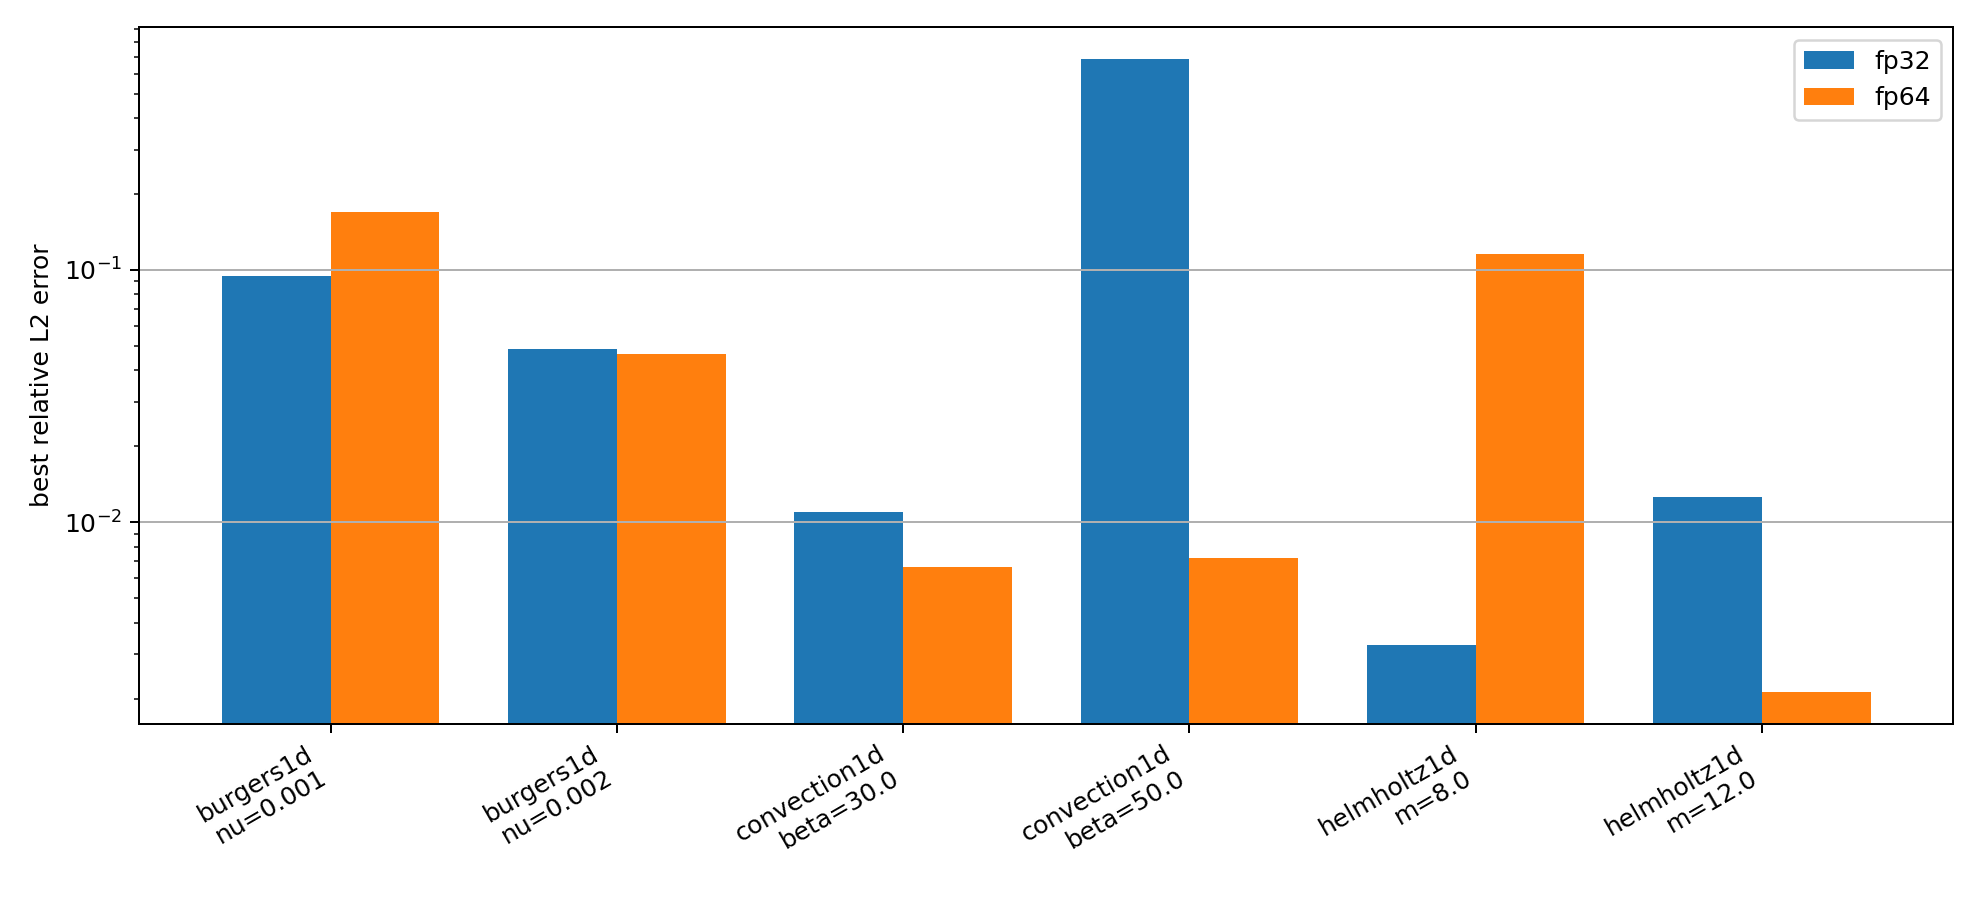

fp64_over_fp32_ratio.png


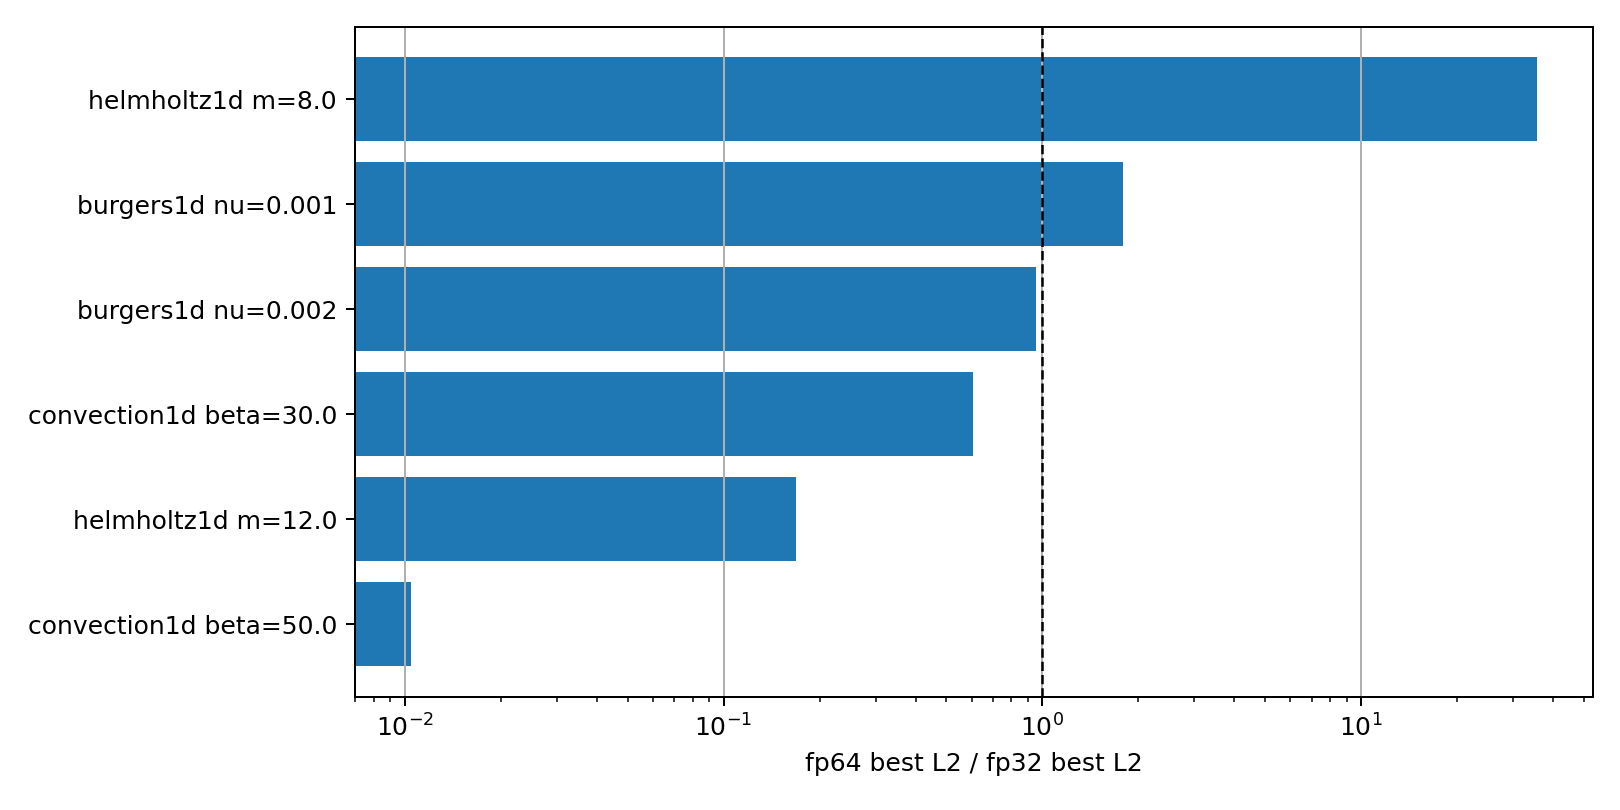

seed_scatter_best_l2.png


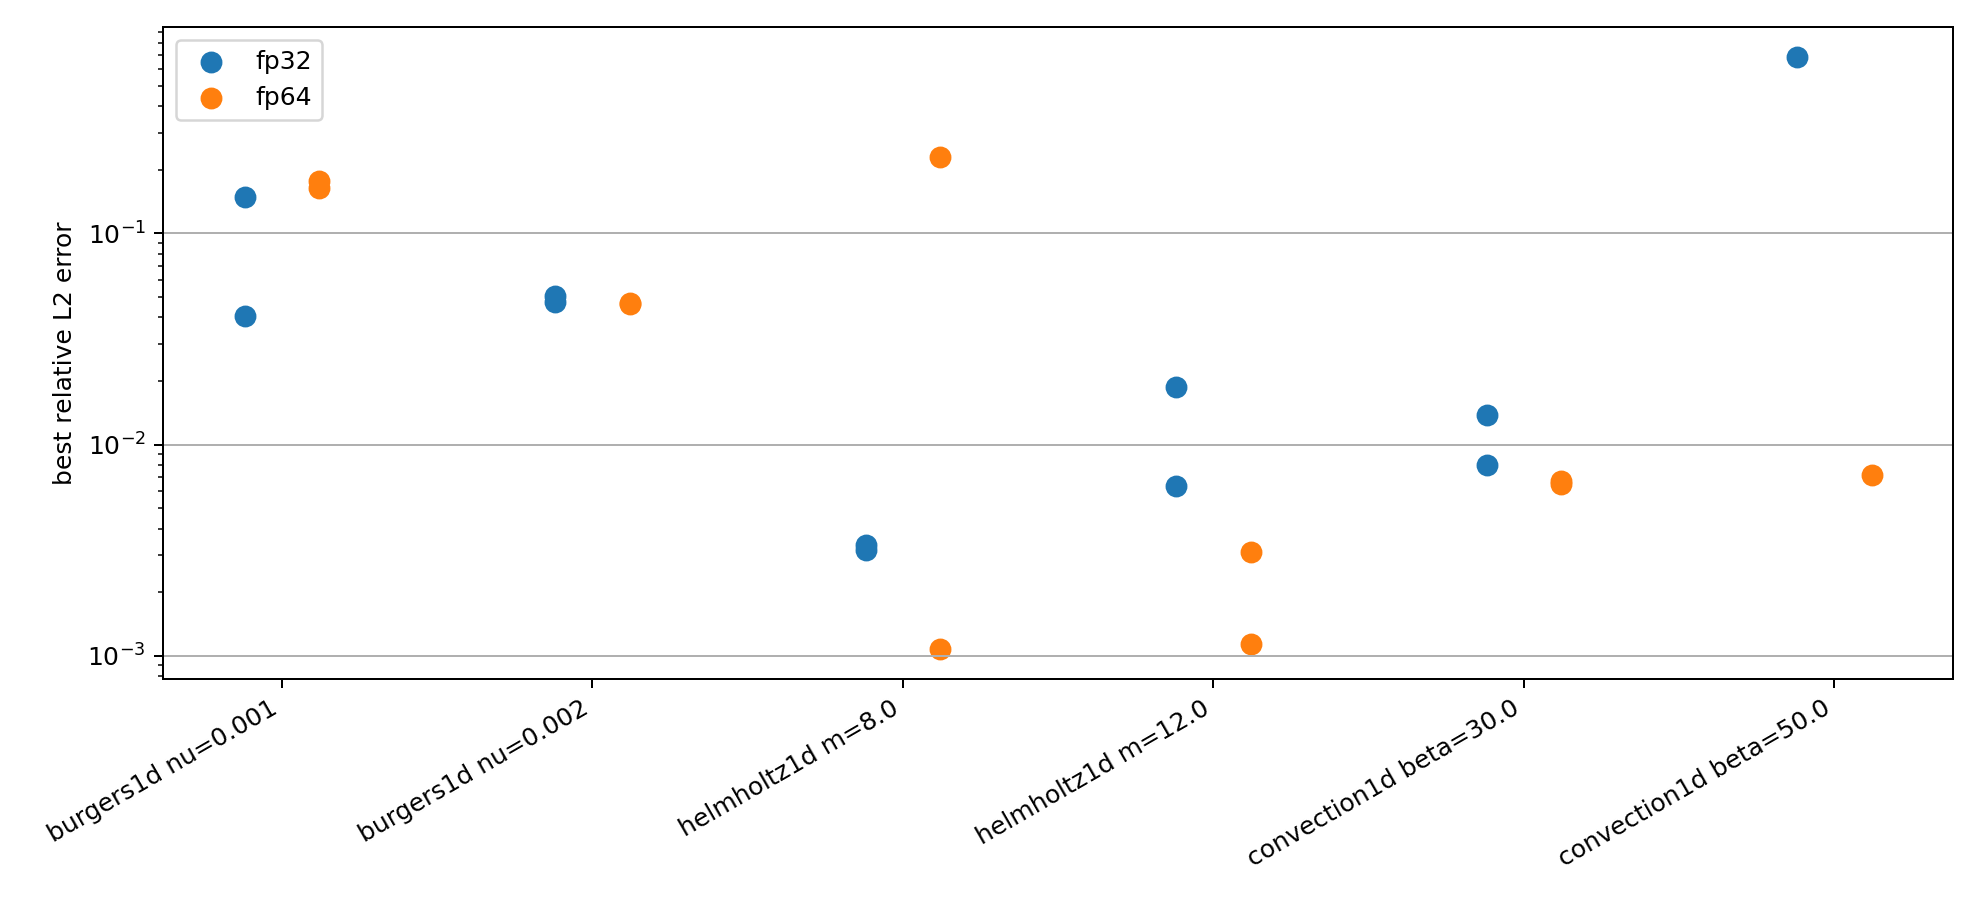

In [11]:
for name in [
    "best_l2_fp32_fp64_bar.png",
    "fp64_over_fp32_ratio.png",
    "seed_scatter_best_l2.png",
]:
    p = out_dir / name
    if p.exists():
        print(name)
        display(Image(filename=str(p)))
